In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split

import numpy as np
import matplotlib.pyplot as plt

In [2]:
stats = ((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))

In [3]:
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(*stats)
])

In [4]:
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(*stats)
])

In [6]:
train_set = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)
test_set = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)

100%|██████████| 170M/170M [01:32<00:00, 1.83MB/s]   
/Users/veronika_steklo/PycharmProjects/ML_NN_SSU/.venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [7]:
train_ds, val_ds = random_split(train_set, [45000, 5000])

In [8]:
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=128, shuffle=False)
test_loader = DataLoader(test_set, batch_size=128, shuffle=False)

In [9]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 10)
        )

    def forward(self, x): return self.network(x)

In [10]:
class MediumCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

In [11]:
class DeepCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = self._make_layer(3, 64)
        self.layer2 = self._make_layer(64, 128)
        self.layer3 = self._make_layer(128, 256)

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, 10)
        )

    def _make_layer(self, in_c, out_c):
        return nn.Sequential(
            nn.Conv2d(in_c, out_c, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        return self.fc(x)

In [12]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

In [13]:
def visualize_errors(model, loader):
    model.eval()
    errors = []
    with torch.no_grad():
        for images, labels in loader:
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            idx = (preds != labels).nonzero(as_tuple=True)[0]
            for i in idx:
                if len(errors) < 5:
                    errors.append((images[i], preds[i], labels[i]))

    fig, axes = plt.subplots(1, 5, figsize=(15, 3))
    classes = train_set.classes
    for i, (img, pred, label) in enumerate(errors):
        img = img.permute(1, 2, 0).numpy()
        axes[i].imshow(np.clip(img * 0.2 + 0.5, 0, 1))
        axes[i].set_title(f"P: {classes[pred]}\nL: {classes[label]}")
        axes[i].axis('off')
    plt.show()

In [14]:
def train_cifar(model, train_loader, val_loader, optimizer_cls, lr=0.001, epochs=20, patience=5):
    optimizer = optimizer_cls(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    early_stopping = EarlyStopping(patience=patience)

    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for images, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        model.eval()
        val_loss = 0
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                outputs = model(images)
                val_loss += criterion(outputs, labels).item()
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        avg_train = train_loss / len(train_loader)
        avg_val = val_loss / len(val_loader)
        acc = 100 * correct / total

        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_train:.3f} | Val Loss: {avg_val:.3f} | Acc: {acc:.2f}%")

        history['train_loss'].append(avg_train)
        history['val_loss'].append(avg_val)
        history['val_acc'].append(acc)

        early_stopping(avg_val)
        if early_stopping.early_stop:
            print("Ранняя остановка")
            break

    return history

In [15]:
models = {
    "Simple": SimpleCNN(),
    "Medium": MediumCNN(),
    "Deep": DeepCNN()
}


=== Модель: Simple ===
Epoch [1/15] | Train Loss: 1.597 | Val Loss: 1.393 | Acc: 50.78%
Epoch [2/15] | Train Loss: 1.346 | Val Loss: 1.302 | Acc: 52.76%
Epoch [3/15] | Train Loss: 1.231 | Val Loss: 1.189 | Acc: 57.92%
Epoch [4/15] | Train Loss: 1.161 | Val Loss: 1.202 | Acc: 57.04%
Epoch [5/15] | Train Loss: 1.117 | Val Loss: 1.121 | Acc: 59.50%
Epoch [6/15] | Train Loss: 1.088 | Val Loss: 1.072 | Acc: 62.48%
Epoch [7/15] | Train Loss: 1.060 | Val Loss: 1.019 | Acc: 64.18%
Epoch [8/15] | Train Loss: 1.033 | Val Loss: 1.042 | Acc: 63.32%
Epoch [9/15] | Train Loss: 1.013 | Val Loss: 1.023 | Acc: 63.44%
Epoch [10/15] | Train Loss: 0.997 | Val Loss: 1.022 | Acc: 64.58%
Ранняя остановка
Ошибки:


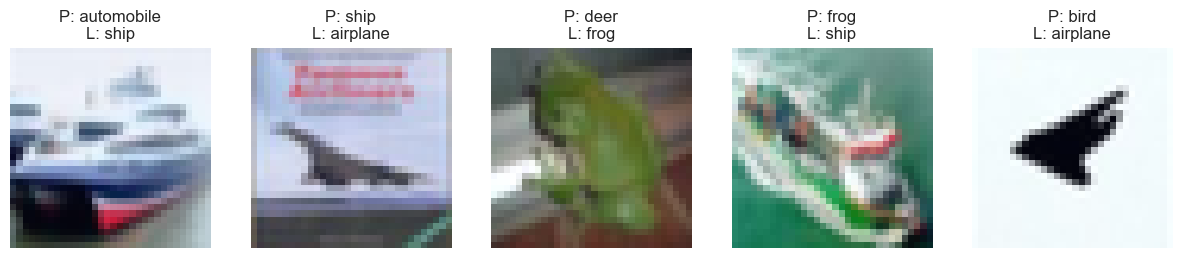


=== Модель: Medium ===
Epoch [1/15] | Train Loss: 1.733 | Val Loss: 1.435 | Acc: 46.76%
Epoch [2/15] | Train Loss: 1.449 | Val Loss: 1.297 | Acc: 53.24%
Epoch [3/15] | Train Loss: 1.353 | Val Loss: 1.185 | Acc: 56.30%
Epoch [4/15] | Train Loss: 1.285 | Val Loss: 1.164 | Acc: 58.46%
Epoch [5/15] | Train Loss: 1.241 | Val Loss: 1.107 | Acc: 59.92%
Epoch [6/15] | Train Loss: 1.201 | Val Loss: 1.088 | Acc: 60.88%
Epoch [7/15] | Train Loss: 1.167 | Val Loss: 1.050 | Acc: 62.08%
Epoch [8/15] | Train Loss: 1.133 | Val Loss: 1.024 | Acc: 62.80%
Epoch [9/15] | Train Loss: 1.120 | Val Loss: 1.034 | Acc: 64.04%
Epoch [10/15] | Train Loss: 1.106 | Val Loss: 1.002 | Acc: 64.36%
Epoch [11/15] | Train Loss: 1.085 | Val Loss: 0.973 | Acc: 65.46%
Epoch [12/15] | Train Loss: 1.068 | Val Loss: 0.968 | Acc: 65.32%
Epoch [13/15] | Train Loss: 1.051 | Val Loss: 0.959 | Acc: 66.06%
Epoch [14/15] | Train Loss: 1.042 | Val Loss: 0.954 | Acc: 65.96%
Epoch [15/15] | Train Loss: 1.035 | Val Loss: 0.941 | Acc: 67

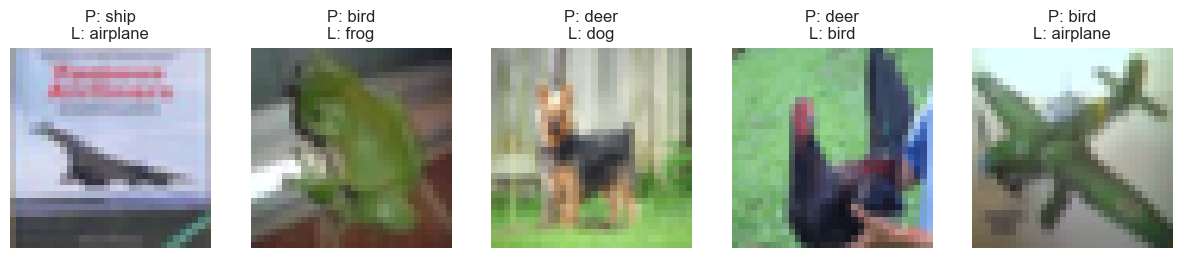


=== Модель: Deep ===
Epoch [1/15] | Train Loss: 1.386 | Val Loss: 1.248 | Acc: 54.76%
Epoch [2/15] | Train Loss: 1.062 | Val Loss: 0.997 | Acc: 64.70%
Epoch [3/15] | Train Loss: 0.939 | Val Loss: 1.019 | Acc: 63.66%
Epoch [4/15] | Train Loss: 0.859 | Val Loss: 0.847 | Acc: 69.78%
Epoch [5/15] | Train Loss: 0.810 | Val Loss: 0.890 | Acc: 69.06%
Epoch [6/15] | Train Loss: 0.759 | Val Loss: 0.757 | Acc: 73.00%
Epoch [7/15] | Train Loss: 0.729 | Val Loss: 0.710 | Acc: 75.48%
Epoch [8/15] | Train Loss: 0.694 | Val Loss: 0.679 | Acc: 76.38%
Epoch [9/15] | Train Loss: 0.665 | Val Loss: 0.661 | Acc: 76.90%
Epoch [10/15] | Train Loss: 0.650 | Val Loss: 0.668 | Acc: 77.14%
Epoch [11/15] | Train Loss: 0.619 | Val Loss: 0.617 | Acc: 78.68%
Epoch [12/15] | Train Loss: 0.596 | Val Loss: 0.620 | Acc: 78.70%
Epoch [13/15] | Train Loss: 0.590 | Val Loss: 0.649 | Acc: 77.90%
Epoch [14/15] | Train Loss: 0.573 | Val Loss: 0.636 | Acc: 77.62%
Ранняя остановка
Ошибки:


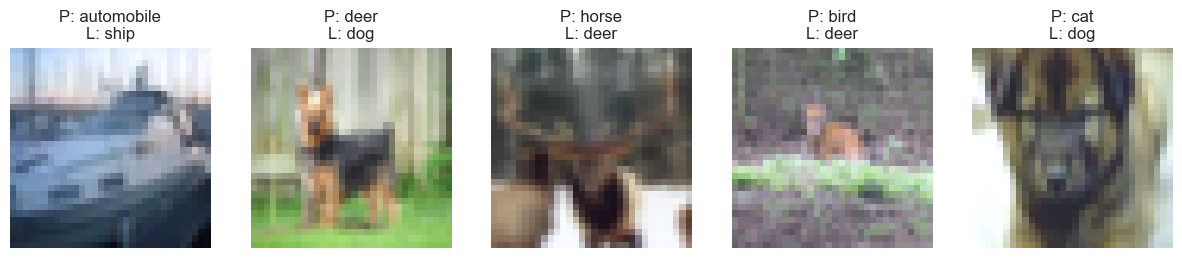

In [18]:
all_results = {}

for name, model in models.items():
    print(f"\n=== Модель: {name} ===")

    history = train_cifar(
        model,
        train_loader,
        val_loader,
        optimizer_cls=optim.Adam,
        epochs=15,
        patience=3
    )
    all_results[name] = history

    print(f"Ошибки:")
    visualize_errors(model, test_loader)

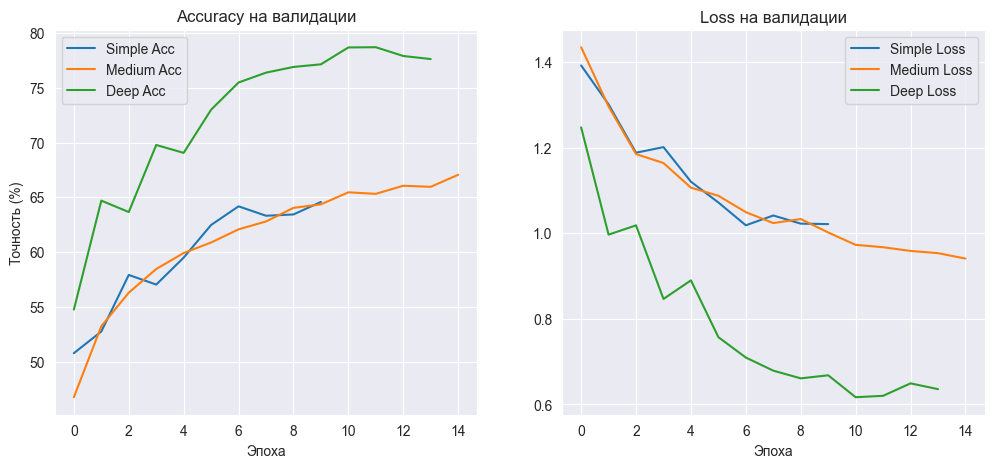

In [19]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for name, hist in all_results.items():
    plt.plot(hist['val_acc'], label=f'{name} Acc')
plt.title('Accuracy на валидации')
plt.xlabel('Эпоха')
plt.ylabel('Точность (%)')
plt.legend()

plt.subplot(1, 2, 2)
for name, hist in all_results.items():
    plt.plot(hist['val_loss'], label=f'{name} Loss')
plt.title('Loss на валидации')
plt.xlabel('Эпоха')
plt.legend()

plt.show()